In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.sans-serif']=['SimHei']   # 支持中文
plt.rcParams['axes.unicode_minus']=False

In [2]:
data=pd.read_excel('海牙地区中餐厅_评分卡模型.xlsx')
data

,餐厅名,评分,评论数,人气指数,人均消费,平均客单价,营业时长,成立时间,经营年限,地理位置,商圈等级,同一地区餐厅数量,竞争指数,网站,社交媒体,外卖,YabandPay客户
0,Feng Shou,4.4,655,28.539107,10-20,15,6.5,1986,40,Escamp,1,5,1.791759,1,1,1,0
1,Noord-Oost Chinees Eethuis,4.4,478,27.155483,20-30,25,10.0,1995,31,Centrum,5,41,3.737670,1,0,1,1
2,Shanghai,4.3,237,23.530764,20-30,25,7.5,1990,36,Centrum,5,41,3.737670,1,0,1,0
3,Sjon Restaurant,4.3,497,26.705580,10-20,15,9.0,2000,26,Escamp,1,5,1.791759,0,0,0,1
4,Kaa Lun Palace,4.0,847,26.971523,20-30,25,9.0,1990,36,Centrum,5,41,3.737670,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Restaurant Bijou,4.3,729,28.350091,40-50,45,6.0,2010,16,Zoetermeer,2,8,2.197225,1,1,1,0
100,Vivi Bubble Tea,4.8,365,28.332640,10-20,15,6.5,2018,8,Zoetermeer,2,8,2.197225,1,1,1,1
101,8tea5,3.7,283,20.901205,10-20,15,8.0,2012,14,Centrum,5,41,3.737670,1,1,1,0
102,Rosarium Westbroekpark,3.9,1344,28.096182,30-40,35,6.0,1980,46,Scheveningen,5,5,1.791759,1,1,0,0


In [3]:
TARGET="YabandPay客户"

candidate_numeric=["人气指数","平均客单价","经营年限","营业时长","竞争指数","商圈等级"]
candidate_binary=["网站","社交媒体","外卖"]
candidate_categorical=["商圈等级"]

numeric_cols=[c for c in candidate_numeric if c in data.columns]
binary_cols=[c for c in candidate_binary if c in data.columns]
cat_cols=[c for c in candidate_categorical if c in data.columns]

print("数值型特征:", numeric_cols)
print("二值特征:", binary_cols)
print("类别特征:", cat_cols)

数值型特征: ['人气指数', '平均客单价', '经营年限', '营业时长', '竞争指数', '商圈等级']
二值特征: ['网站', '社交媒体', '外卖']
类别特征: ['商圈等级']


In [4]:
display(data[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
人气指数,104.0,23.838497,4.579300,9.670857,21.401384,23.925986,27.167223,33.905673
平均客单价,104.0,19.855769,11.647257,5.000000,15.000000,15.000000,25.000000,100.000000
经营年限,104.0,19.788462,12.945497,1.000000,7.000000,16.000000,31.000000,46.000000
营业时长,104.0,7.990385,1.908057,4.000000,6.000000,8.500000,9.500000,11.000000
竞争指数,104.0,2.771509,0.926749,0.693147,1.945910,2.944439,3.737670,3.737670
商圈等级,104.0,3.769231,1.345476,1.000000,2.750000,4.000000,5.000000,5.000000


In [5]:
spearman_results=[]

for col in numeric_cols:
    df_tmp=data[[col, TARGET]].dropna()
    if df_tmp[TARGET].nunique()<=1:
        continue
    r, p=spearmanr(df_tmp[col], df_tmp[TARGET])
    spearman_results.append({'变量': col, 'SpearmanR': r, 'P值': p})

spearman_df=pd.DataFrame(spearman_results).sort_values(by='SpearmanR', ascending=False)
print("数值型特征与目标的 Spearman 相关性：")
display(spearman_df)

数值型特征与目标的 Spearman 相关性：


,变量,SpearmanR,P值
3,营业时长,0.311532,0.001286
1,平均客单价,0.146308,0.138337
4,竞争指数,0.133984,0.175104
0,人气指数,0.111006,0.261935
5,商圈等级,0.092785,0.348856
2,经营年限,-0.157525,0.110261


In [6]:
vif_df=pd.DataFrame()
vif_df['变量']=numeric_cols
X_vif=data[numeric_cols].dropna()
vif_values=[]

for i in range(X_vif.shape[1]):
    vif_values.append(variance_inflation_factor(X_vif.values, i))

vif_df['VIF']=vif_values

print("数值变量的 VIF：")
display(vif_df)

数值变量的 VIF：


,变量,VIF
0,人气指数,21.075572
1,平均客单价,4.472463
2,经营年限,3.419048
3,营业时长,19.344931
4,竞争指数,29.432141
5,商圈等级,25.982135


In [7]:
def bin_and_check_monotonic(df, feature, target,
                             n_bins=5,              # 希望最终最多几个箱
                             monotonic_trend="auto",# "auto" / "ascending" / "descending"
                             init_bins=20,          # 初始细分箱数（越大越细）
                             min_bin_pct=0.05,      # 每个箱最小样本占比
                             plot=True):

    tmp = df[[feature, target]].dropna().copy()
    tmp = tmp.sort_values(feature)
    x = tmp[feature].values
    y = tmp[target].values

    n = len(tmp)
    if n == 0:
        raise ValueError("数据为空，无法分箱。")

    # 1. 初始等频分箱（在排序后的序号上切分）
    indices = np.arange(n)
    groups = np.array_split(indices, min(init_bins, n))

    bins = []
    for g in groups:
        if len(g) == 0:
            continue
        xv = x[g]
        yv = y[g]
        count = len(g)
        good = (yv == 1).sum()
        bad = (yv == 0).sum()
        bins.append({
            "left": xv.min(),
            "right": xv.max(),
            "count": count,
            "good": good,
            "bad": bad,
            "event_rate": good / count if count > 0 else 0.0,
            "mean_x": xv.mean()
        })

    # 小工具：合并两个相邻箱
    def merge_two(b1, b2):
        total_count = b1["count"] + b2["count"]
        if total_count == 0:
            event_rate = 0.0
            mean_x = 0.0
        else:
            event_rate = (b1["good"] + b2["good"]) / total_count
            mean_x = (b1["mean_x"] * b1["count"] + b2["mean_x"] * b2["count"]) / total_count
        return {
            "left": b1["left"],
            "right": b2["right"],
            "count": total_count,
            "good": b1["good"] + b2["good"],
            "bad": b1["bad"] + b2["bad"],
            "event_rate": event_rate,
            "mean_x": mean_x
        }

    # 2. 合并掉样本太少的箱
    min_count = max(1, int(min_bin_pct * n))
    merged = True
    while merged and len(bins) > 1:
        merged = False
        for i, b in enumerate(bins):
            if b["count"] < min_count:
                # 和相邻箱合并：优先选择样本数更少的邻居
                if i == 0:
                    j = 1
                elif i == len(bins) - 1:
                    j = i - 1
                else:
                    j = i - 1 if bins[i - 1]["count"] <= bins[i + 1]["count"] else i + 1

                new_bin = merge_two(bins[min(i, j)], bins[max(i, j)])

                new_bins = []
                for k, b2 in enumerate(bins):
                    if k in (i, j):
                        continue
                    new_bins.append(b2)
                new_bins.append(new_bin)
                new_bins = sorted(new_bins, key=lambda d: d["left"])
                bins = new_bins
                merged = True
                break

    # 3. 判断单调方向
    er = np.array([b["event_rate"] for b in bins])
    mx = np.array([b["mean_x"] for b in bins])

    if monotonic_trend == "auto":
        if len(bins) >= 2 and er.std() > 0:
            corr = np.corrcoef(mx, er)[0, 1]
            trend = "ascending" if corr >= 0 else "descending"
        else:
            trend = "ascending"
    else:
        trend = monotonic_trend

    def is_monotonic(er_values, mode):
        if mode == "ascending":
            return np.all(np.diff(er_values) >= -1e-12)
        else:  # descending
            return np.all(np.diff(er_values) <= 1e-12)

    # 4. 合并相邻箱，强制单调 + 控制箱数不超过 n_bins
    while (len(bins) > n_bins) or (not is_monotonic(er, trend) and len(bins) > 1):
        viol_index = None
        if trend == "ascending":
            for i in range(len(er) - 1):
                if er[i+1] < er[i] - 1e-12:
                    viol_index = i
                    break
        else:  # descending
            for i in range(len(er) - 1):
                if er[i+1] > er[i] + 1e-12:
                    viol_index = i
                    break

        if viol_index is None:
            # 已单调，但箱数仍然 > n_bins，就随便合并最后两个
            viol_index = len(bins) - 2

        new_bin = merge_two(bins[viol_index], bins[viol_index + 1])
        new_bins = []
        for k, b in enumerate(bins):
            if k in (viol_index, viol_index + 1):
                continue
            new_bins.append(b)
        new_bins.append(new_bin)
        new_bins = sorted(new_bins, key=lambda d: d["left"])
        bins = new_bins
        er = np.array([b["event_rate"] for b in bins])

    # 5. 计算 WOE / IV
    total_good = (y == 1).sum()
    total_bad = (y == 0).sum()
    eps = 1e-6

    rows = []
    for b in bins:
        dist_good = b["good"] / total_good if total_good > 0 else 0
        dist_bad = b["bad"] / total_bad if total_bad > 0 else 0
        woe = np.log((dist_good + eps) / (dist_bad + eps)) if dist_good > 0 and dist_bad > 0 else 0.0
        iv = (dist_good - dist_bad) * woe
        rows.append({
            "bin": f"[{b['left']:.4f}, {b['right']:.4f}]",
            "总数": b["count"],
            "good(1)": b["good"],
            "bad(0)": b["bad"],
            "客户率": b["event_rate"],
            "dist_good": dist_good,
            "dist_bad": dist_bad,
            "WOE": woe,
            "IV": iv
        })

    bin_table = pd.DataFrame(rows)

    print(f"\n===== {feature} 的WOE和IV =====")
    display(bin_table)

    # 6. 画图
    if plot and len(bin_table) > 0:
        x_axis = range(len(bin_table))
        x_labels = bin_table["bin"].astype(str)

        # 客户率曲线
        plt.figure()
        plt.plot(x_axis, bin_table["客户率"], marker='o')
        plt.xticks(x_axis, x_labels, rotation=45)
        plt.ylabel("客户率")
        plt.title(f"{feature} 分箱后客户率（单调性检查）")
        plt.tight_layout()
        plt.show()

        # WOE 曲线
        plt.figure()
        plt.plot(x_axis, bin_table["WOE"], marker='o')
        plt.xticks(x_axis, x_labels, rotation=45)
        plt.ylabel("WOE")
        plt.title(f"{feature} 分箱后 WOE（单调性检查）")
        plt.tight_layout()
        plt.show()

    return bin_table


===== 人气指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[9.6709, 15.8235]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[16.2311, 19.8933]",12,3,9,0.250000,0.061224,0.163636,-0.983089,0.100680
2,"[20.1423, 21.6027]",11,5,6,0.454545,0.102041,0.109091,-0.066808,0.000471
3,"[21.6819, 33.9057]",75,40,35,0.533333,0.816327,0.636364,0.249044,0.044819


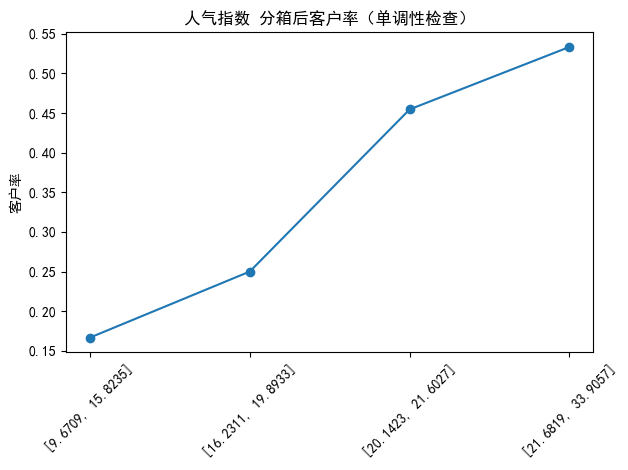

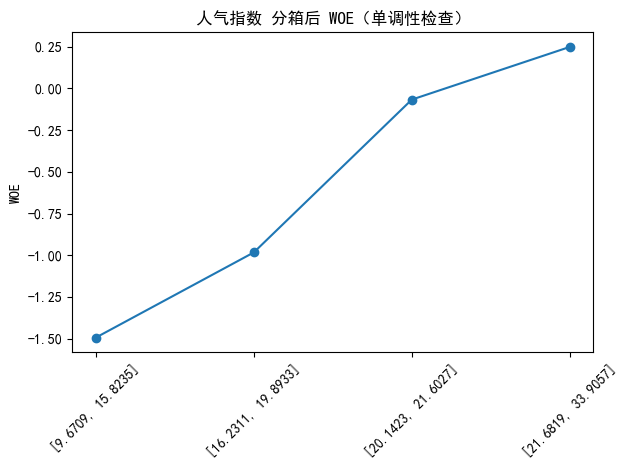


===== 平均客单价 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[5.0000, 5.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
1,"[5.0000, 15.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
2,"[15.0000, 15.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[15.0000, 15.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
4,"[15.0000, 100.0000]",82,41,41,0.500000,0.836735,0.745455,0.115513,0.010544


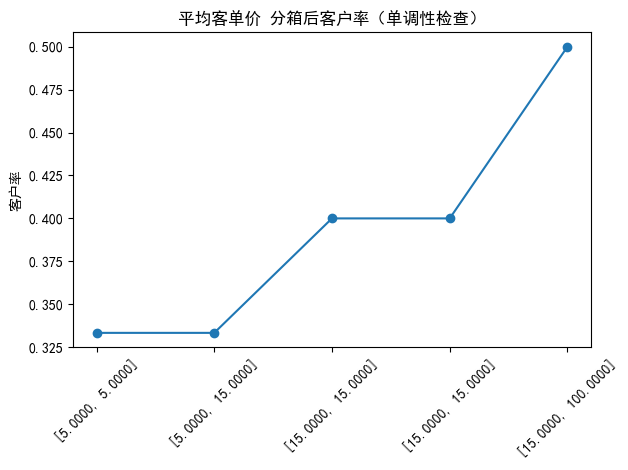

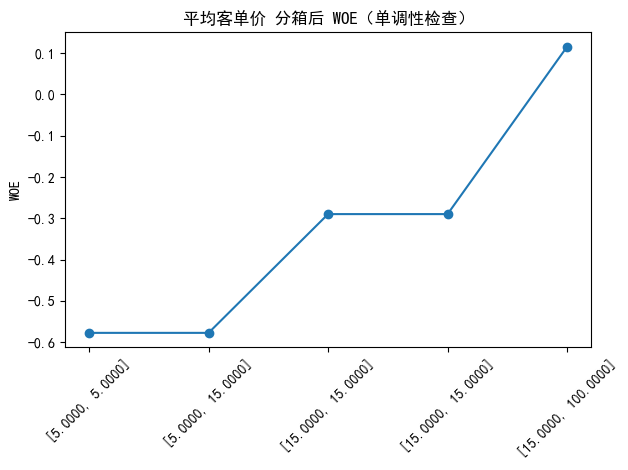


===== 经营年限 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[1.0000, 14.0000]",44,25,19,0.568182,0.510204,0.345455,0.389949,0.064244
1,"[14.0000, 26.0000]",20,10,10,0.500000,0.204082,0.181818,0.115512,0.002572
2,"[26.0000, 31.0000]",10,5,5,0.500000,0.102041,0.090909,0.115512,0.001286
3,"[31.0000, 40.0000]",25,8,17,0.320000,0.163265,0.309091,-0.638256,0.093074
4,"[41.0000, 46.0000]",5,1,4,0.200000,0.020408,0.072727,-1.270746,0.066484


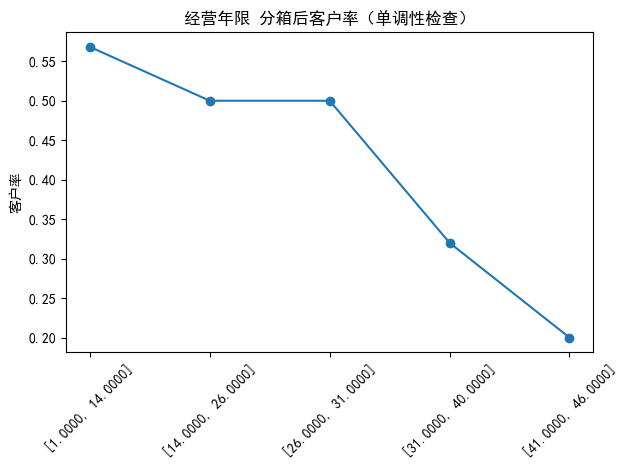

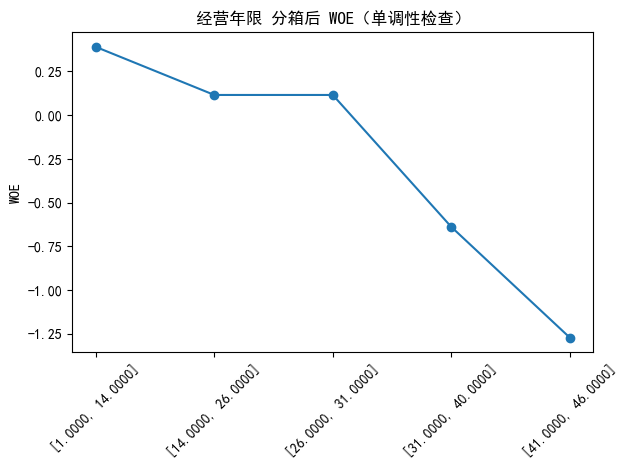


===== 营业时长 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[4.0000, 5.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[5.0000, 7.5000]",33,9,24,0.272727,0.183673,0.436364,-0.865313,0.218656
2,"[7.5000, 8.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[8.0000, 8.5000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
4,"[8.5000, 11.0000]",55,35,20,0.636364,0.714286,0.363636,0.675127,0.236733


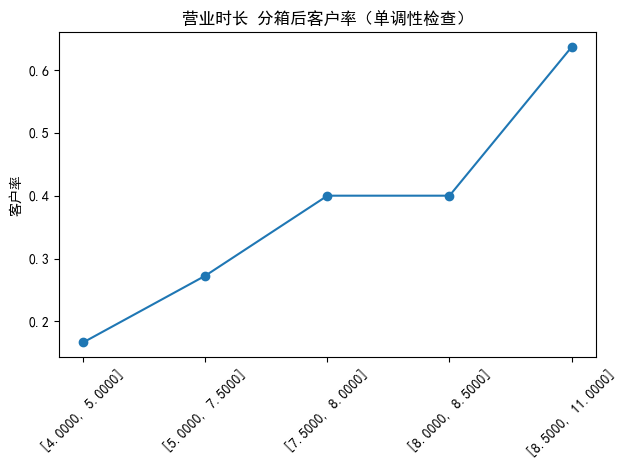

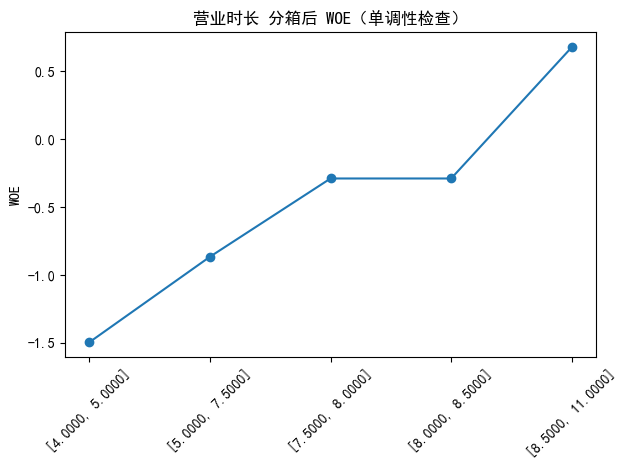


===== 竞争指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[0.6931, 2.1972]",34,12,22,0.352941,0.244898,0.400000,-0.490621,0.076096
1,"[2.1972, 3.7377]",40,16,24,0.400000,0.326531,0.436364,-0.289951,0.031846
2,"[3.7377, 3.7377]",30,21,9,0.700000,0.428571,0.163636,0.962807,0.255081


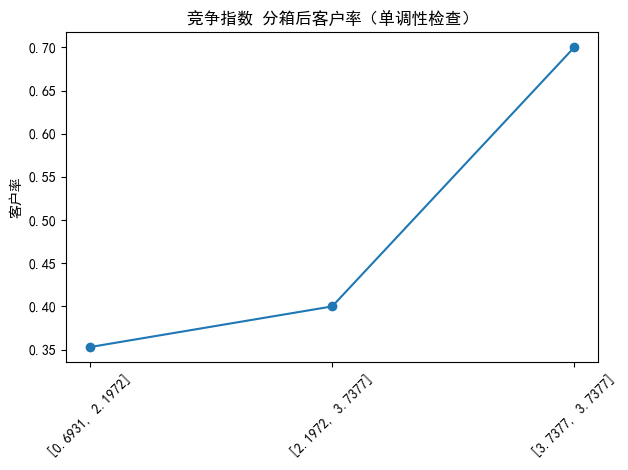

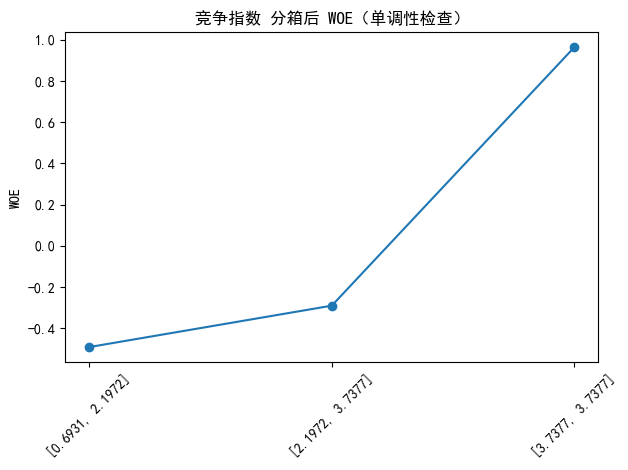


===== 商圈等级 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[1.0000, 1.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
1,"[2.0000, 2.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
2,"[2.0000, 3.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[2.0000, 2.0000]",12,5,7,0.416667,0.102041,0.127273,-0.220957,0.005575
4,"[3.0000, 5.0000]",75,38,37,0.506667,0.775510,0.672727,0.142181,0.014614


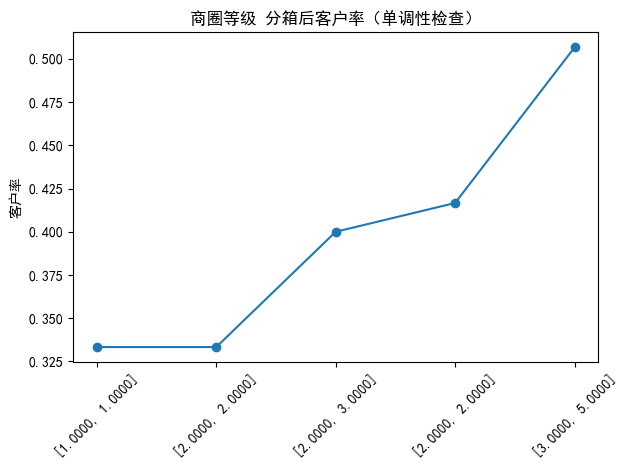

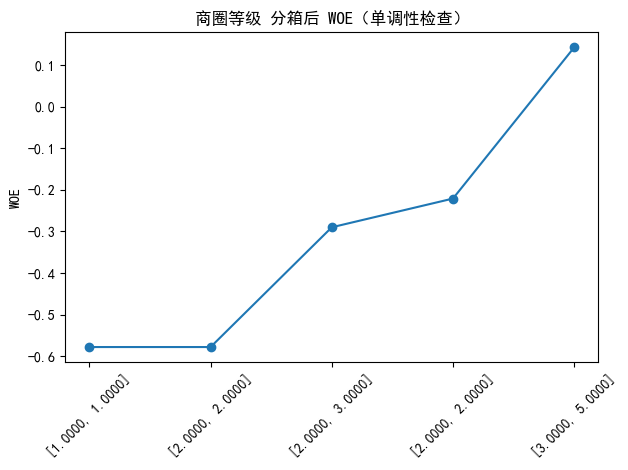

In [8]:
for col in numeric_cols:
    _ = bin_and_check_monotonic(data, col, TARGET, n_bins=5, plot=True)

In [9]:
def woe_for_binary(df, feature, target):
    
    tmp = df[[feature, target]].dropna()
    total_good = (tmp[target] == 1).sum()
    total_bad  = (tmp[target] == 0).sum()
    eps = 1e-6

    rows = []
    for val, sub in tmp.groupby(feature):
        good = (sub[target] == 1).sum()
        bad  = (sub[target] == 0).sum()
        total = good + bad

        # 各组占比
        dist_good = good / total_good if total_good > 0 else eps
        dist_bad  = bad  / total_bad  if total_bad  > 0 else eps

        # WOE
        woe = np.log((dist_good + eps) / (dist_bad + eps))

        # 该组对 IV 的贡献
        iv = (dist_good - dist_bad) * woe

        rows.append({
            feature: val,          # 这一组的取值（或分箱标签）
            '总数': total,
            'good(1)': good,
            'bad(0)': bad,
            '客户率': good / total if total > 0 else 0.0,
            'dist_good': dist_good,
            'dist_bad': dist_bad,
            'WOE': woe,
            'IV': iv
        })

    result = pd.DataFrame(rows)

    # 你如果想顺便看一下这个变量的总 IV，也可以：
    #print(f"{feature} 的总 IV = {result['IV'].sum():.6f}")

    return result

for col in binary_cols:
    print(f'\n===== {col} 的WOE和IV =====')
    display(woe_for_binary(data, col, TARGET))


===== 网站 的WOE和IV =====


,网站,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,0,11,5,6,0.454545,0.102041,0.109091,-0.066808,0.000471
1,1,93,44,49,0.473118,0.897959,0.890909,0.007882,0.000056



===== 社交媒体 的WOE和IV =====


,社交媒体,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,0,42,20,22,0.476190,0.408163,0.4,0.020203,0.000165
1,1,62,29,33,0.467742,0.591837,0.6,-0.013699,0.000112



===== 外卖 的WOE和IV =====


,外卖,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,0,43,16,27,0.372093,0.326531,0.490909,-0.407734,0.067023
1,1,61,33,28,0.540984,0.673469,0.509091,0.279815,0.045996



===== 人气指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[9.6709, 15.8235]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[16.2311, 19.8933]",12,3,9,0.250000,0.061224,0.163636,-0.983089,0.100680
2,"[20.1423, 21.6027]",11,5,6,0.454545,0.102041,0.109091,-0.066808,0.000471
3,"[21.6819, 33.9057]",75,40,35,0.533333,0.816327,0.636364,0.249044,0.044819


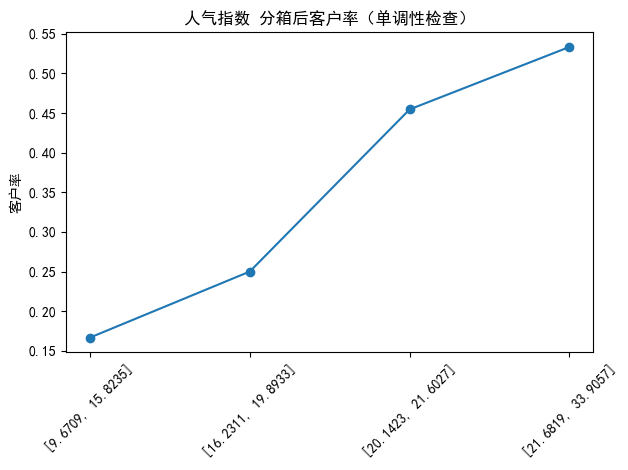

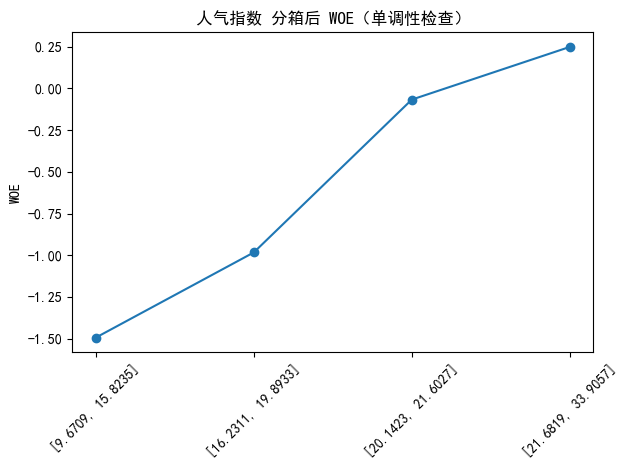


===== 平均客单价 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[5.0000, 5.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
1,"[5.0000, 15.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
2,"[15.0000, 15.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[15.0000, 15.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
4,"[15.0000, 100.0000]",82,41,41,0.500000,0.836735,0.745455,0.115513,0.010544


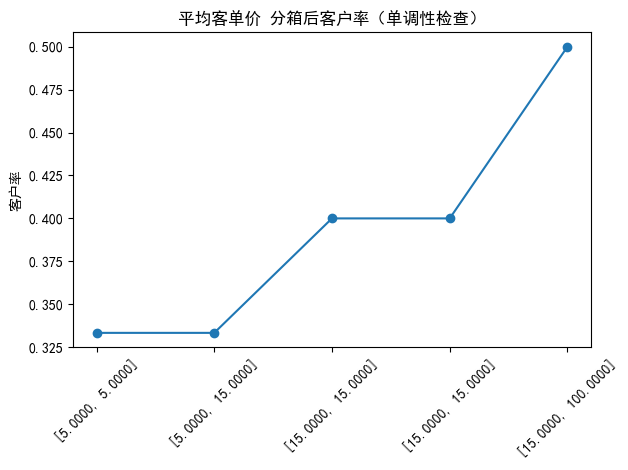

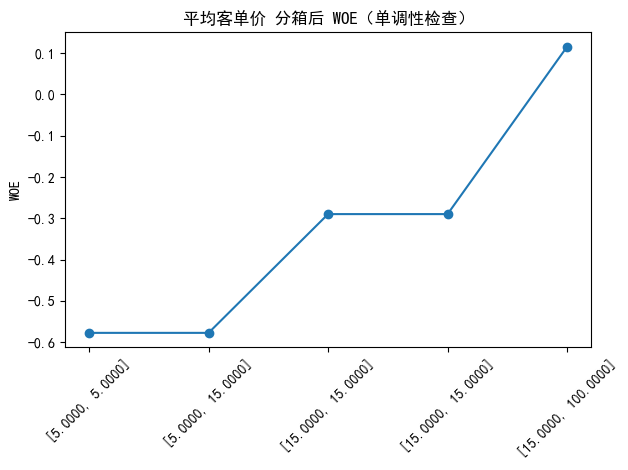


===== 经营年限 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[1.0000, 14.0000]",44,25,19,0.568182,0.510204,0.345455,0.389949,0.064244
1,"[14.0000, 26.0000]",20,10,10,0.500000,0.204082,0.181818,0.115512,0.002572
2,"[26.0000, 31.0000]",10,5,5,0.500000,0.102041,0.090909,0.115512,0.001286
3,"[31.0000, 40.0000]",25,8,17,0.320000,0.163265,0.309091,-0.638256,0.093074
4,"[41.0000, 46.0000]",5,1,4,0.200000,0.020408,0.072727,-1.270746,0.066484


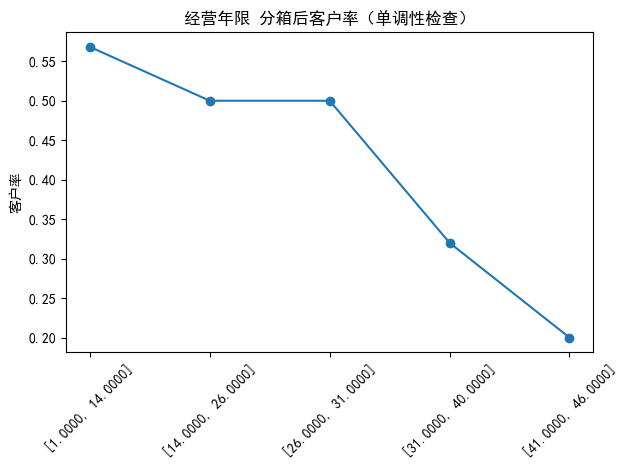

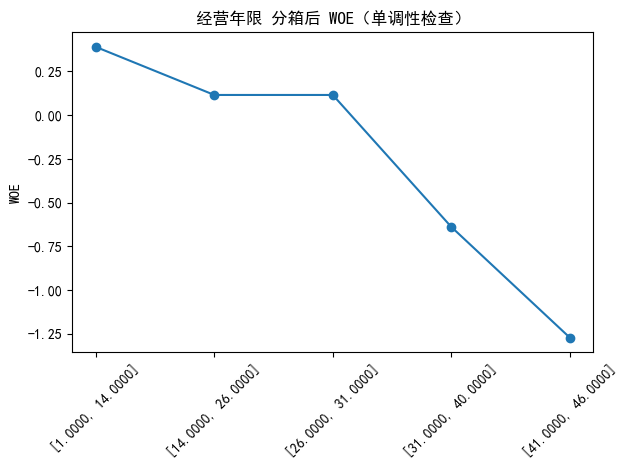


===== 营业时长 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[4.0000, 5.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[5.0000, 7.5000]",33,9,24,0.272727,0.183673,0.436364,-0.865313,0.218656
2,"[7.5000, 8.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[8.0000, 8.5000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
4,"[8.5000, 11.0000]",55,35,20,0.636364,0.714286,0.363636,0.675127,0.236733


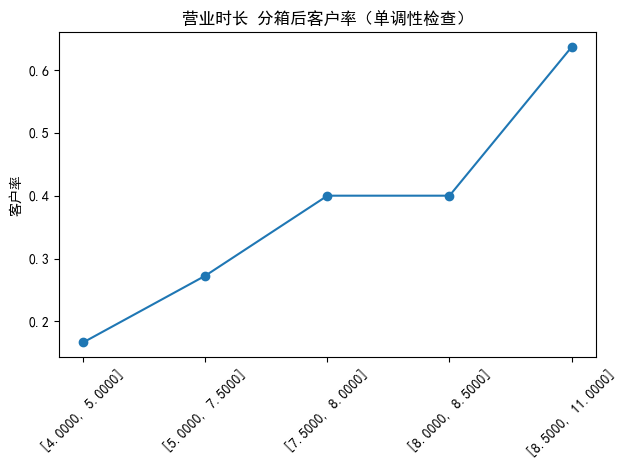

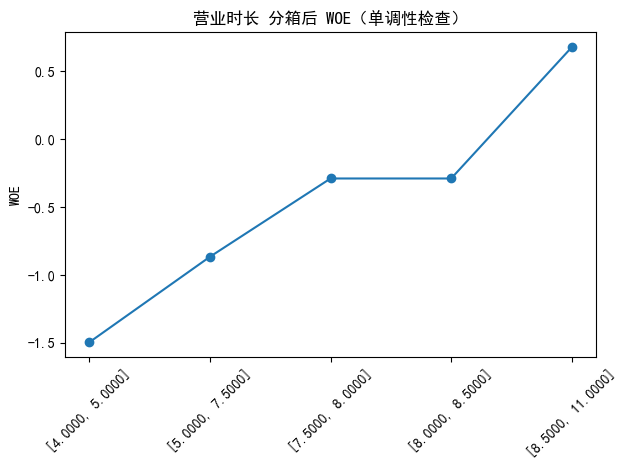


===== 竞争指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[0.6931, 2.1972]",34,12,22,0.352941,0.244898,0.400000,-0.490621,0.076096
1,"[2.1972, 3.7377]",40,16,24,0.400000,0.326531,0.436364,-0.289951,0.031846
2,"[3.7377, 3.7377]",30,21,9,0.700000,0.428571,0.163636,0.962807,0.255081


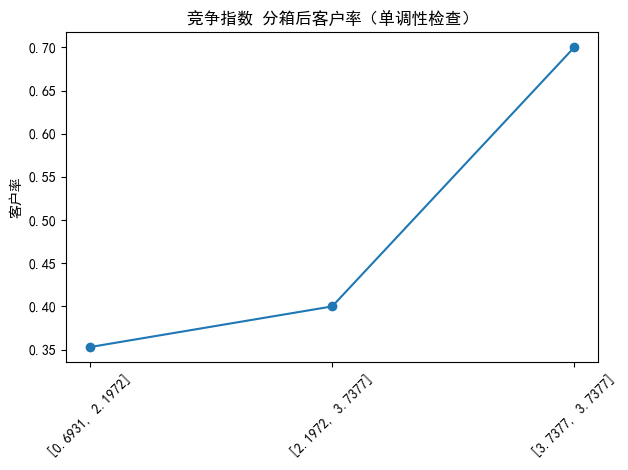

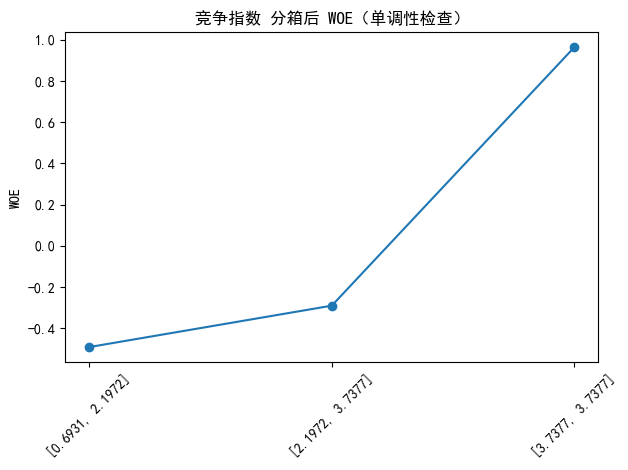


===== 商圈等级 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[1.0000, 1.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
1,"[2.0000, 2.0000]",6,2,4,0.333333,0.040816,0.072727,-0.577624,0.018433
2,"[2.0000, 3.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[2.0000, 2.0000]",12,5,7,0.416667,0.102041,0.127273,-0.220957,0.005575
4,"[3.0000, 5.0000]",75,38,37,0.506667,0.775510,0.672727,0.142181,0.014614


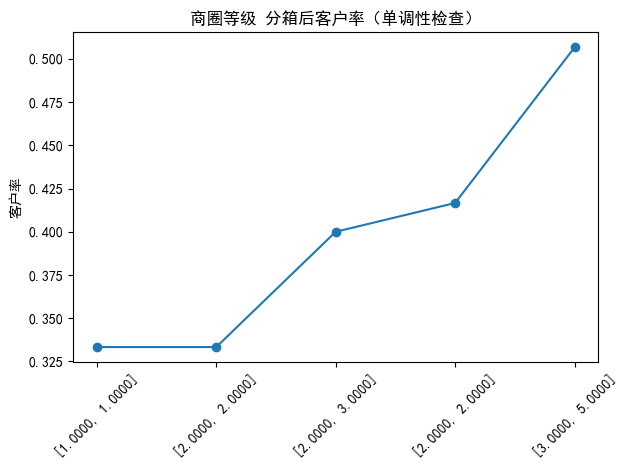

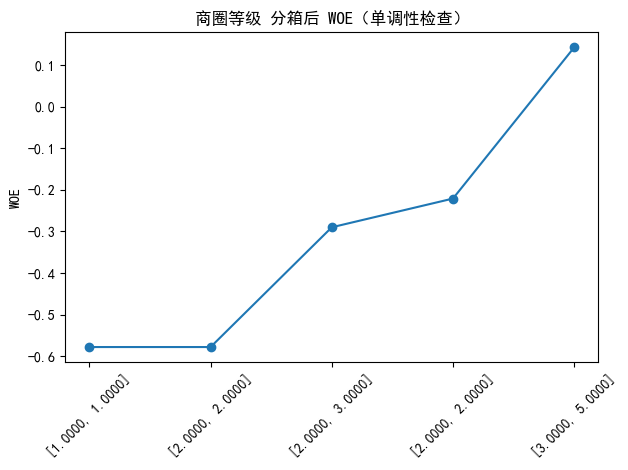

,变量名,类型,IV
3,营业时长,数值型,0.568671
4,竞争指数,数值型,0.363024
0,人气指数,数值型,0.251290
2,经营年限,数值型,0.227660
8,外卖,二值型,0.113018
5,商圈等级,数值型,0.061035
1,平均客单价,数值型,0.055370
6,网站,二值型,0.000527
7,社交媒体,二值型,0.000277


In [10]:
numeric_iv_results = []

for col in numeric_cols:
    bin_table = bin_and_check_monotonic(data, col, TARGET)
    total_iv = bin_table["IV"].sum()
    numeric_iv_results.append({"变量名":col,"类型":"数值型","IV":total_iv})
    
binary_iv_results = []

for col in binary_cols:
    bin_table = woe_for_binary(data, col, TARGET)
    total_iv = bin_table["IV"].sum()
    binary_iv_results.append({"变量名": col,"类型": "二值型","IV": total_iv})

results = numeric_iv_results + binary_iv_results    
iv_table = pd.DataFrame(results).sort_values(by="IV", ascending=False)
display(iv_table)

In [11]:
def apply_woe(series, bin_table):
    woe_list = []
    
    for val in series:
        assigned = False
        for _, row in bin_table.iterrows():
            # 解析区间
            left, right = row["bin"][1:-1].split(",")
            left, right = float(left), float(right)

            if left <= val <= right:
                woe_list.append(row["WOE"])
                assigned = True
                break
        
        if not assigned:
            woe_list.append(0)  # 如果没命中箱（极少数情况）
    
    return np.array(woe_list)

In [12]:
selected_vars=["营业时长", "竞争指数", "人气指数", "经营年限", "外卖"]

bin_营业时长 = bin_and_check_monotonic(data, "营业时长", TARGET, n_bins=5, plot=False)
bin_竞争指数 = bin_and_check_monotonic(data, "竞争指数", TARGET, n_bins=5, plot=False)
bin_人气指数 = bin_and_check_monotonic(data, "人气指数", TARGET, n_bins=5, plot=False)
bin_经营年限 = bin_and_check_monotonic(data, "经营年限", TARGET, n_bins=5, plot=False)
bin_外卖 = bin_and_check_monotonic(data, "外卖", TARGET, n_bins=5, plot=False)

bin_map = {"营业时长": bin_营业时长,"竞争指数": bin_竞争指数,"人气指数": bin_人气指数, "经营年限": bin_经营年限,"外卖": bin_外卖}

# 用 WOE 转换所有变量
X_woe = pd.DataFrame()

for var in selected_vars:
    X_woe[var+"_WOE"] = apply_woe(data[var], bin_map[var])

y = data[TARGET]


===== 营业时长 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[4.0000, 5.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[5.0000, 7.5000]",33,9,24,0.272727,0.183673,0.436364,-0.865313,0.218656
2,"[7.5000, 8.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[8.0000, 8.5000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
4,"[8.5000, 11.0000]",55,35,20,0.636364,0.714286,0.363636,0.675127,0.236733



===== 竞争指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[0.6931, 2.1972]",34,12,22,0.352941,0.244898,0.400000,-0.490621,0.076096
1,"[2.1972, 3.7377]",40,16,24,0.400000,0.326531,0.436364,-0.289951,0.031846
2,"[3.7377, 3.7377]",30,21,9,0.700000,0.428571,0.163636,0.962807,0.255081



===== 人气指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[9.6709, 15.8235]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[16.2311, 19.8933]",12,3,9,0.250000,0.061224,0.163636,-0.983089,0.100680
2,"[20.1423, 21.6027]",11,5,6,0.454545,0.102041,0.109091,-0.066808,0.000471
3,"[21.6819, 33.9057]",75,40,35,0.533333,0.816327,0.636364,0.249044,0.044819



===== 经营年限 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[1.0000, 14.0000]",44,25,19,0.568182,0.510204,0.345455,0.389949,0.064244
1,"[14.0000, 26.0000]",20,10,10,0.500000,0.204082,0.181818,0.115512,0.002572
2,"[26.0000, 31.0000]",10,5,5,0.500000,0.102041,0.090909,0.115512,0.001286
3,"[31.0000, 40.0000]",25,8,17,0.320000,0.163265,0.309091,-0.638256,0.093074
4,"[41.0000, 46.0000]",5,1,4,0.200000,0.020408,0.072727,-1.270746,0.066484



===== 外卖 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[0.0000, 0.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[0.0000, 0.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
2,"[0.0000, 0.0000]",5,1,4,0.200000,0.020408,0.072727,-1.270746,0.066484
3,"[0.0000, 1.0000]",37,16,21,0.432432,0.326531,0.381818,-0.156420,0.008648
4,"[1.0000, 1.0000]",50,30,20,0.600000,0.612245,0.363636,0.520977,0.129519


In [13]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=1000)
logit.fit(X_woe, y)

coef_df = pd.DataFrame({"变量": X_woe.columns,"系数": logit.coef_[0]})

print("\n基于 WOE 的 Logistic 回归模型系数：\n")
print(coef_df)

print("\n截距（Interecept）=", logit.intercept_[0])


基于 WOE 的 Logistic 回归模型系数：

         变量        系数
0  营业时长_WOE  0.813462
1  竞争指数_WOE  0.081427
2  人气指数_WOE  0.883606
3  经营年限_WOE  0.517816
4    外卖_WOE  0.437289

截距（Interecept）= 0.23662130228509634


In [14]:
# 1. 取出模型参数：系数 β 和 截距 β0
betas = logit.coef_[0]          # 对应 X_woe 各列的系数
intercept = logit.intercept_[0] # 截距 β0
feature_woe_cols = X_woe.columns.tolist()

coef_df = pd.DataFrame({
    "WOE变量名": feature_woe_cols,
    "系数β": betas
})
print("===== 基于 WOE 的 Logistic 回归系数 =====")
display(coef_df)
print("截距 β0 =", intercept)

# 2. 设置信用评分卡的刻度参数（你可以自己改这些数字）
PDO = 50           # 每翻倍赔率对应的分数差，常见取 20 / 30 / 50
BASE_SCORE = 600   # 基准分，例如 600 分
BASE_ODDS = 1/20   # 基准点的好坏赔率（Good/Bad），这里假设 1:20，可根据业务改

# 3. 计算 Factor 和 Offset（评分卡数学标准公式）
Factor = PDO / np.log(2)  # 每单位 log(odds) 对应的分数
Offset = BASE_SCORE + Factor * (np.log(BASE_ODDS) - intercept)

print("\n===== 评分卡刻度参数 =====")
print("PDO        =", PDO)
print("BASE_SCORE =", BASE_SCORE)
print("BASE_ODDS  =", BASE_ODDS)
print("Factor     =", Factor)
print("Offset     =", Offset)

# 4. 计算每一个样本的总分： Score = Offset + Factor * Σ(β_j * WOE_j)
linear_part = X_woe.values @ betas          # Σ(β_j * WOE_j)
scores = Offset + Factor * linear_part      # 每一行的总分

# 把分数加回到原始数据里
data["scorecard_score"] = scores

# print("\n===== 部分样本的评分卡分数预览 =====")
# display(data[["scorecard_score"]].head())

# 5. 生成“每个变量每个分箱的分值表”（方便将来部署评分卡用）
scorecard_tables = {}  # {变量名: 分箱得分表}

for col_woe, beta in zip(feature_woe_cols, betas):
    # 去掉 "_WOE" 得到原始变量名（你就是这么命名的）
    orig_var = col_woe.replace("_WOE", "")
    
    # 找到该变量的分箱表（里面有 bin, WOE 列）
    bt = bin_map[orig_var].copy()
    
    # 每个分箱的分值 = Factor * β * WOE（不包含 Offset）
    bt["Score_contrib"] = Factor * beta * bt["WOE"]
    
    scorecard_tables[orig_var] = bt[["bin", "WOE", "Score_contrib"]]

    print(f"\n===== 变量的分箱评分表 =====")
    display(scorecard_tables[orig_var])

===== 基于 WOE 的 Logistic 回归系数 =====


,WOE变量名,系数β
0,营业时长_WOE,0.813462
1,竞争指数_WOE,0.081427
2,人气指数_WOE,0.883606
3,经营年限_WOE,0.517816
4,外卖_WOE,0.437289


截距 β0 = 0.23662130228509634

===== 评分卡刻度参数 =====
PDO        = 50
BASE_SCORE = 600
BASE_ODDS  = 0.05
Factor     = 72.13475204444818
Offset     = 366.834976286862

===== 变量的分箱评分表 =====


,bin,WOE,Score_contrib
0,"[4.0000, 5.0000]",-1.493887,-87.659626
1,"[5.0000, 7.5000]",-0.865313,-50.775615
2,"[7.5000, 8.0000]",-0.289946,-17.013711
3,"[8.0000, 8.5000]",-0.289946,-17.013711
4,"[8.5000, 11.0000]",0.675127,39.615719



===== 变量的分箱评分表 =====


...

,bin,WOE,Score_contrib
0,"[9.6709, 15.8235]",-1.493887,-95.218386
1,"[16.2311, 19.8933]",-0.983089,-62.660806
2,"[20.1423, 21.6027]",-0.066808,-4.258256
3,"[21.6819, 33.9057]",0.249044,15.873731



===== 变量的分箱评分表 =====


,bin,WOE,Score_contrib
0,"[1.0000, 14.0000]",0.389949,14.565583
1,"[14.0000, 26.0000]",0.115512,4.314679
2,"[26.0000, 31.0000]",0.115512,4.314656
3,"[31.0000, 40.0000]",-0.638256,-23.840492
4,"[41.0000, 46.0000]",-1.270746,-47.465616



===== 变量的分箱评分表 =====


,bin,WOE,Score_contrib
0,"[0.0000, 0.0000]",-1.493887,-47.122730
1,"[0.0000, 0.0000]",-1.493887,-47.122730
2,"[0.0000, 0.0000]",-1.270746,-40.084042
3,"[0.0000, 1.0000]",-0.156420,-4.934078
4,"[1.0000, 1.0000]",0.520977,16.433540


In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_auc_ks(y_true, score, plot_roc=True):
    
    # ---- AUC ----
    auc_value = roc_auc_score(y_true, score)

    # ---- KS ----
    # 按 score 从高到低排序（分数越高越“好客户”）
    df = pd.DataFrame({"y": y_true, "score": score}).sort_values("score", ascending=False)

    # 这里假设 y=1 为“好样本/客户”，y=0 为“坏样本/非客户”
    df["good"] = (df["y"] == 1).astype(int)
    df["bad"]  = (df["y"] == 0).astype(int)

    total_good = df["good"].sum()
    total_bad  = df["bad"].sum()

    df["cum_good_pct"] = df["good"].cumsum() / (total_good if total_good > 0 else 1)
    df["cum_bad_pct"]  = df["bad"].cumsum()  / (total_bad  if total_bad  > 0 else 1)

    df["ks"] = df["cum_good_pct"] - df["cum_bad_pct"]
    ks_value = df["ks"].max()

    # ---- 可选：画 ROC 曲线 ----
    if plot_roc:
        fpr, tpr, _ = roc_curve(y_true, score)
        import matplotlib.pyplot as plt
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.grid(alpha=0.4, linestyle="--")
        plt.tight_layout()
        plt.show()

    return auc_value, ks_value, df  # df 里面有 KS 曲线明细

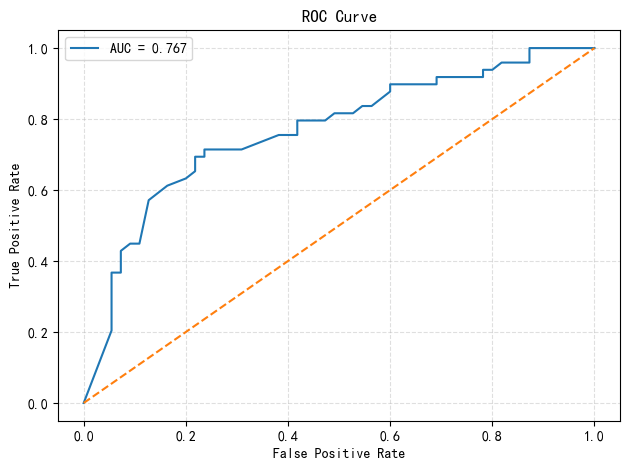

AUC = 0.7672
KS  = 0.4779


In [16]:
# 例如：用全部样本做一次评估
auc_value, ks_value, ks_df = evaluate_auc_ks(
    y_true=data[TARGET],
    score=data["scorecard_score"],   # 也可以换成预测概率 y_pred_prob
    plot_roc=True
)

print(f"AUC = {auc_value:.4f}")
print(f"KS  = {ks_value:.4f}")

In [17]:

# ===================== 0. 读入数据 =====================
# 换成你本地的路径即可
data = pd.read_excel("海牙地区中餐厅_评分卡模型.xlsx")

TARGET = "YabandPay客户"

# 选择参与评分卡的变量（你已经定好的5个）
selected_vars = ["营业时长", "竞争指数", "人气指数", "经营年限", "外卖"]


# ===================== 1. 分箱 + 计算 WOE（用你之前的函数） =====================
# 这里假设你已经在前面定义好了这个函数：
# bin_and_check_monotonic(df, feature, target, n_bins=5, monotonic_trend="auto", ...)

bin_map = {}   # {变量名: 该变量的分箱表（含 WOE）}

for col in selected_vars:
    print(f"\n===== 对变量做单调分箱并计算 WOE =====")
    bin_table = bin_and_check_monotonic(
        data,
        feature=col,
        target=TARGET,
        n_bins=5,
        plot=False   # 此处不画图，想看可以改成 True
    )
    bin_map[col] = bin_table   # 保存起来，后面做 WOE 转换会用到


# ===================== 2. 原始值 → WOE 值（第三步 & 第四步） =====================
def apply_woe(series, bin_table):
    """
    把一个变量的一列原始数值，按分箱表映射成对应的 WOE 值
    bin_table 必须包含列：["bin", "WOE"]
    bin 形如 "[a, b]"
    """
    woe_list = []
    for val in series:
        assigned = False
        for _, row in bin_table.iterrows():
            # 解析区间字符串，比如 "[0.0000, 3.0000]"
            left_str, right_str = row["bin"][1:-1].split(",")
            left, right = float(left_str), float(right_str)
            if left <= val <= right:
                woe_list.append(row["WOE"])
                assigned = True
                break
        if not assigned:
            # 极少数不在任何区间的值（理论上不会发生），给 0
            woe_list.append(0.0)
    return np.array(woe_list)

# 构造 WOE 特征矩阵 X_woe
X_woe = pd.DataFrame(index=data.index)

for col in selected_vars:
    bt = bin_map[col]
    X_woe[col + "_WOE"] = apply_woe(data[col], bt)

y = data[TARGET]


# ===================== 3. 用 WOE 做 Logistic 回归（评分卡指定算法） =====================
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=1000, solver="lbfgs")
logit.fit(X_woe, y)

betas = logit.coef_[0]          # 各 WOE 变量的系数 β
intercept = logit.intercept_[0] # 截距 β0

coef_df = pd.DataFrame({
    "WOE变量名": X_woe.columns,
    "系数β": betas
})
print("\n===== 基于 WOE 的 Logistic 回归系数 =====")
print(coef_df)
print("\n截距 β0 =", intercept)


# ===================== 4. 把 Logistic 输出变成 300–900 分（步骤 9） =====================
# 先计算每条样本的 logit：β0 + Σ(β_j * WOE_j)
linear_part = intercept + X_woe.values @ betas   # shape = (n_samples,)

# 再把 linear_part 线性映射到 [300, 900] 区间
lin_min = linear_part.min()
lin_max = linear_part.max()
if lin_max == lin_min:
    raise ValueError("linear_part 没变化，检查模型或数据。")

score_min = 300
score_max = 900
score_range = score_max - score_min

scores = score_min + (linear_part - lin_min) / (lin_max - lin_min) * score_range

# 写回原始 data，每家餐厅的评分卡总分
data["scorecard_score"] = scores

print("\n===== 部分样本的评分卡分数预览 =====")
print(data[["餐厅名", "scorecard_score"]].head())


# ===================== 5. ABCD 分层 =====================
def assign_segment(score):
    """
    根据分数做 ABCD 档位：
    A：高潜力（>=700）
    B：中高潜力（650–700）
    C：一般（600–650）
    D：低潜力（<600）
    """
    if score >= 700:
        return "A"
    elif score >= 650:
        return "B"
    elif score >= 600:
        return "C"
    else:
        return "D"

data["segment"] = data["scorecard_score"].apply(assign_segment)

print("\n===== 分层结果示例（餐厅 + 分数 + 档位） =====")
print(data[["餐厅名", "scorecard_score", "segment"]].head())

print("\n===== 各档位数量统计 =====")
print(data["segment"].value_counts().sort_index())


# ===================== 6. 如需导出结果到 Excel =====================
# 把打分 + 分层后的结果保存成一个新文件
data.to_excel("海牙地区中餐厅_评分卡打分结果.xlsx", index=False)
print("\n评分卡打分与分层已导出到：海牙地区中餐厅_评分卡打分结果.xlsx")



===== 对变量做单调分箱并计算 WOE =====

===== 营业时长 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[4.0000, 5.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[5.0000, 7.5000]",33,9,24,0.272727,0.183673,0.436364,-0.865313,0.218656
2,"[7.5000, 8.0000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
3,"[8.0000, 8.5000]",5,2,3,0.400000,0.040816,0.054545,-0.289946,0.003981
4,"[8.5000, 11.0000]",55,35,20,0.636364,0.714286,0.363636,0.675127,0.236733



===== 对变量做单调分箱并计算 WOE =====

===== 竞争指数 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[0.6931, 2.1972]",34,12,22,0.352941,0.244898,0.400000,-0.490621,0.076096
1,"[2.1972, 3.7377]",40,16,24,0.400000,0.326531,0.436364,-0.289951,0.031846
2,"[3.7377, 3.7377]",30,21,9,0.700000,0.428571,0.163636,0.962807,0.255081



===== 对变量做单调分箱并计算 WOE =====

===== 人气指数 的WOE和IV =====


...


===== 对变量做单调分箱并计算 WOE =====

===== 经营年限 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[1.0000, 14.0000]",44,25,19,0.568182,0.510204,0.345455,0.389949,0.064244
1,"[14.0000, 26.0000]",20,10,10,0.500000,0.204082,0.181818,0.115512,0.002572
2,"[26.0000, 31.0000]",10,5,5,0.500000,0.102041,0.090909,0.115512,0.001286
3,"[31.0000, 40.0000]",25,8,17,0.320000,0.163265,0.309091,-0.638256,0.093074
4,"[41.0000, 46.0000]",5,1,4,0.200000,0.020408,0.072727,-1.270746,0.066484



===== 对变量做单调分箱并计算 WOE =====

===== 外卖 的WOE和IV =====


,bin,总数,good(1),bad(0),客户率,dist_good,dist_bad,WOE,IV
0,"[0.0000, 0.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
1,"[0.0000, 0.0000]",6,1,5,0.166667,0.020408,0.090909,-1.493887,0.105320
2,"[0.0000, 0.0000]",5,1,4,0.200000,0.020408,0.072727,-1.270746,0.066484
3,"[0.0000, 1.0000]",37,16,21,0.432432,0.326531,0.381818,-0.156420,0.008648
4,"[1.0000, 1.0000]",50,30,20,0.600000,0.612245,0.363636,0.520977,0.129519



===== 基于 WOE 的 Logistic 回归系数 =====
     WOE变量名       系数β
0  营业时长_WOE  0.813462
1  竞争指数_WOE  0.081427
2  人气指数_WOE  0.883606
3  经营年限_WOE  0.517816
4    外卖_WOE  0.437289

截距 β0 = 0.23662130228509634

===== 部分样本的评分卡分数预览 =====
                          餐厅名  scorecard_score
0                   Feng Shou       599.394008
1  Noord-Oost Chinees Eethuis       876.291870
2                    Shanghai       602.120030
3             Sjon Restaurant       775.992864
4              Kaa Lun Palace       811.175227

===== 分层结果示例（餐厅 + 分数 + 档位） =====
                          餐厅名  scorecard_score segment
0                   Feng Shou       599.394008       D
1  Noord-Oost Chinees Eethuis       876.291870       A
2                    Shanghai       602.120030       C
3             Sjon Restaurant       775.992864       A
4              Kaa Lun Palace       811.175227       A

===== 各档位数量统计 =====
segment
A    50
B    12
C     9
D    33
Name: count, dtype: int64

评分卡打分与分层已导出到：海牙地区中餐厅_评分卡打分结果.xlsx
